/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


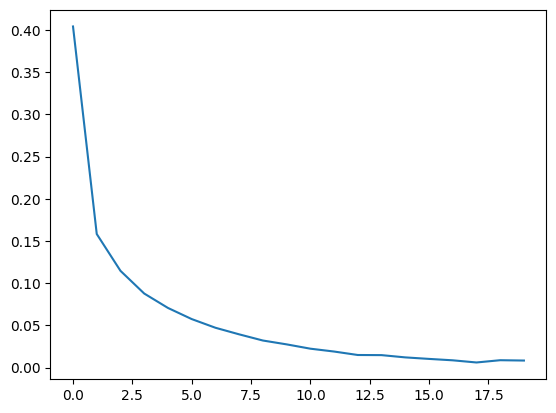

0.9777857142857143

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import joblib

mnist = fetch_openml('mnist_784', version=1)
X = mnist.data / 255.0
y = mnist.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MLPClassifier(hidden_layer_sizes=(128,64), activation='relu', max_iter=20)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

plt.plot(model.loss_curve_)
plt.show()

joblib.dump(model, "sklearn_model.pkl")

acc

In [12]:
from google.colab import files
files.download("sklearn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

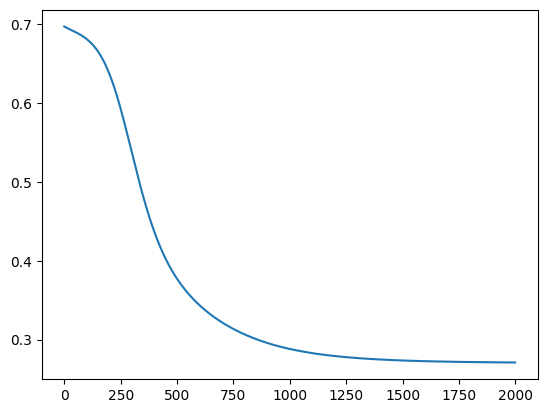

np.float64(0.848)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=2000, noise=0.2)
y = y.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y)

def sigmoid(z):
    return 1/(1+np.exp(-z))

def forward(X, W1,b1,W2,b2):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return z1,a1,z2,a2

def loss(y,yhat):
    return -np.mean(y*np.log(yhat+1e-8)+(1-y)*np.log(1-yhat+1e-8))

W1 = np.random.randn(2,8)*0.1
b1 = np.zeros((1,8))
W2 = np.random.randn(8,1)*0.1
b2 = np.zeros((1,1))

losses = []

for i in range(2000):
    z1,a1,z2,a2 = forward(X_train,W1,b1,W2,b2)
    l = loss(y_train,a2)
    losses.append(l)

    dz2 = a2 - y_train
    dW2 = a1.T @ dz2 / len(X_train)
    db2 = np.sum(dz2,0,keepdims=True)/len(X_train)

    dz1 = (dz2 @ W2.T) * a1*(1-a1)
    dW1 = X_train.T @ dz1 / len(X_train)
    db1 = np.sum(dz1,0,keepdims=True)/len(X_train)

    W1 -= 0.1*dW1
    b1 -= 0.1*db1
    W2 -= 0.1*dW2
    b2 -= 0.1*db2

plt.plot(losses)
plt.show()

_,_,_,pred = forward(X_test,W1,b1,W2,b2)
pred = (pred>0.5).astype(int)

np.mean(pred==y_test)

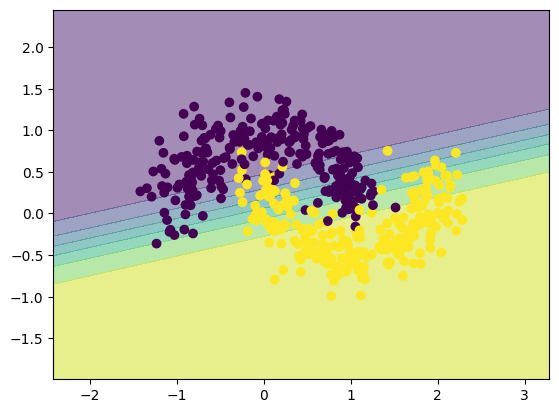

In [14]:
import matplotlib.pyplot as plt

def plot_boundary(X,y,W1,b1,W2,b2):
    x_min,x_max = X[:,0].min()-1,X[:,0].max()+1
    y_min,y_max = X[:,1].min()-1,X[:,1].max()+1

    xx,yy = np.meshgrid(np.linspace(x_min,x_max,200),
                        np.linspace(y_min,y_max,200))

    grid = np.c_[xx.ravel(),yy.ravel()]
    _,_,_,a2 = forward(grid,W1,b1,W2,b2)

    Z = a2.reshape(xx.shape)

    plt.contourf(xx,yy,Z,alpha=0.5)
    plt.scatter(X[:,0],X[:,1],c=y.ravel())
    plt.show()

plot_boundary(X_test,y_test,W1,b1,W2,b2)

In [15]:
import pandas as pd

df = pd.DataFrame({
    "Model":["Sklearn ANN","Scratch ANN"],
    "Accuracy":[acc, np.mean(pred==y_test)]
})

df

,Model,Accuracy
0,Sklearn ANN,0.977786
1,Scratch ANN,0.848000
